# DeepSeek-V4.1-Flash on 4× CMP 170HX: rerun with all four cards at x16, and the all-reduce choice again

| Measured, int4 Engram, DSpark k=5, 140 W | One card x8, hybrid (2026-10-03) | All x16, hybrid (image default) | **All x16, NCCL only (recommended)** |
|---|---:|---:|---:|
| Decode, 1 user: structured / code / prose (tok/s) | 97.8 / 74.7 / 51.2 | 99.4 / 69.7 / 51.1 | **119.9 / 87.4 / 62.5** |
| Decode, 4 users total: structured / code / prose (tok/s) | 224.2 / 150.5 / 112.6 | 273.8 / 141.2 / 124.0 | **271.3 / 148.9 / 127.4** |
| Prefill, 7k–51k prompt tokens (tok/s) | 981–1,262 | 976–1,430 | 976–1,417 |
| Known-answer checks | 5 / 5 | 5 / 5 | 5 / 5 |

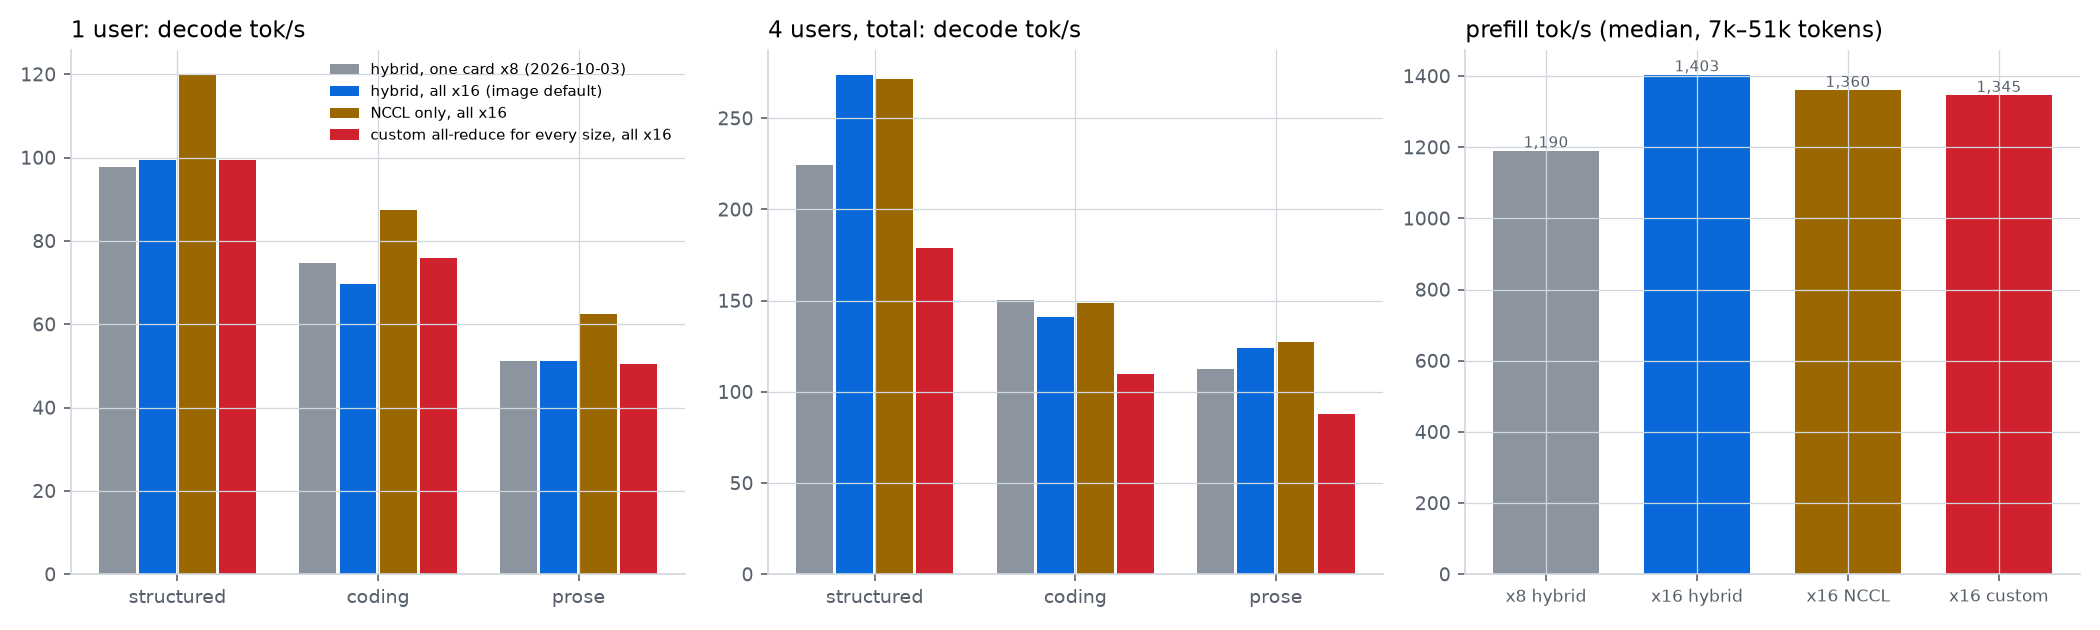

**Verdict (measured):** with all four cards at PCIe Gen2 x16, NCCL alone is the best all-reduce for this model on this host. Against the image default (custom all-reduce below 128 KiB), it decodes one user 21–25% faster at the same draft acceptance, and four users and prefill stay the same. On 2026-10-03, with one card at x8, the custom kernel was faster for one user on code; the wider link removes that advantage. Set `-e CUSTOM_AR=0 -e VLLM_FORCE_CUSTOM_AR_PCIE=0` on hosts like this one.

```
docker pull ghcr.io/pixelml/club-170hx@sha256:b8b7a1699bf272855a9b8c8b316f796b3ef917696302baf2a62c856707d69932
```

In [1]:
# --- Status cell ---
import os
EXPERIMENT = "2026-10-04-deepseek-v4.1-flash-exl3-4card-tp4ep4-x16-allreduce-vllm"
RECEIPTS = "../results/" + EXPERIMENT + "/receipts"
OLD_RECEIPTS = "../results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/receipts"
LIVE = False  # True sends the final request to the endpoint in DSV41_URL (an OpenAI-compatible /v1 base)
ENDPOINT_ENV_VAR = "DSV41_URL"
print("LIVE =", LIVE, "| receipts:", RECEIPTS)

LIVE = False | receipts: ../results/2026-10-04-deepseek-v4.1-flash-exl3-4card-tp4ep4-x16-allreduce-vllm/receipts


In [2]:
# --- Helpers ---
import json, csv, statistics
from IPython.display import display, Markdown
import matplotlib
import matplotlib.pyplot as plt

def table(header, rows):
    out = ["| " + " | ".join(header) + " |", "|" + "|".join("---:" if i else "---" for i in range(len(header))) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    display(Markdown("\n".join(out)))

PROMPTS = ("structured", "coding", "prose")
RUNS = [(OLD_RECEIPTS + "/dspark-k5-int4-ram", "hybrid, one card x8 (2026-10-03)"),
        (RECEIPTS + "/int4-hybrid-x16", "hybrid, all x16 (image default)"),
        (RECEIPTS + "/int4-nccl-x16", "NCCL only, all x16"),
        (RECEIPTS + "/int4-custom-x16", "custom all-reduce for every size, all x16")]
def dec(d, p, c):
    j = json.load(open(f"{d}/decode-{p}-c{c}.json"))
    return j["tok_s_median"] if c == 1 else j["aggregate_tok_s_median"], j["accepted_per_step_median"]
def prefill(d):
    return [r["prefill_tok_s"] for r in json.load(open(f"{d}/prefill.json"))["results"]]
def correct(d):
    j = json.load(open(f"{d}/correctness.json"))
    return f"{j['correct']} / {j['total']}"
def peak_temp(d):
    p = f"{d}/telemetry.csv"
    if not os.path.exists(p):
        return "–"
    t = []
    for r in list(csv.reader(open(p), skipinitialspace=True))[1:]:
        try: t.append(float(r[2]))
        except (ValueError, IndexError): pass
    return f"{max(t):.0f}" if t else "–"

INK, INK2, GRID = "#1f2328", "#57606a", "#d0d7de"
S = ["#8c959f", "#0969da", "#9a6700", "#cf222e"]
matplotlib.rcParams.update({"axes.edgecolor": GRID, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
                            "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False,
                            "axes.spines.right": False, "font.size": 9})

## 1. TL;DR

- **Measured:** with all four cards at x16 and the image defaults, prefill is 18% faster (median 1,190 → 1,403 tok/s) and four users on structured text 22% faster (273.8 vs 224.2 tok/s) than with one card at x8. One-user decode does not change.
- **Measured:** NCCL only (`CUSTOM_AR=0`) decodes one user at 119.9 / 87.4 / 62.5 tok/s: +21% / +25% / +22% against the default hybrid all-reduce, with the same accepted tokens per step on structured text (4.97). Four users and prefill are within 5%.
- **Measured:** the custom all-reduce for every message size slows four users by 22–35%, as it did at x8.
- **Measured:** all three configurations pass the 5 known-answer checks. Peak core temperature stays below 80 °C.
- **Inferred:** at x8, the narrow link made NCCL's ring slower than the custom kernel's direct peer reads for small messages. At x16, NCCL is faster at every size here. The 2026-10-04 DeepSeek-V4-Flash-Vision notebook found the same on this host (NCCL about 100 µs vs 186 µs per call).

In [3]:
pins = {
    "served image": "ghcr.io/pixelml/club-170hx@sha256:b8b7a1699bf272855a9b8c8b316f796b3ef917696302baf2a62c856707d69932 (unchanged from the 2026-10-03 notebook)",
    "build recipe and patches": "results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, patched files, int4 converter, launch.sh)",
    "base image": "ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3)",
    "EXL3 checkpoint": "Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT)",
    "Engram tables": "deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT), int4 copy pinned in host RAM (DSV41_ENGRAM_DISK=0 DSV41_ENGRAM_INT4=1)",
    "drafter": "DSpark from the checkpoint's MTP layers, num_speculative_tokens 5",
    "all-reduce arms": "hybrid = image defaults (CUSTOM_AR=1, VLLM_CUSTOM_AR_MAX_BYTES=131072); NCCL only = -e CUSTOM_AR=0 -e VLLM_FORCE_CUSTOM_AR_PCIE=0; custom for every size = -e VLLM_CUSTOM_AR_MAX_BYTES=0",
    "serve arguments": "image entrypoint (build/launch.sh): TP4 + expert parallel, exl3, 65,536 context, fp8 KV, 4 sequences, 8,192 batched tokens, CUDA graphs 1-24",
    "driver": "NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504",
    "host": "Proxmox VE 9.2, kernel 7.0.2-6-pve, 251 GB RAM, 2 NUMA nodes; privileged LXC, 192 GiB limit, both NUMA nodes",
    "topology": "two PLX switches, PCIe Gen2; all four cards x16 in this notebook (one card was x8 on 2026-10-03); nvidia-smi-start.csv per run",
    "power / HBM": "nvidia-smi -pl 140; HBM 1,728 MHz on all cards (170tune NDIV 64)",
}
table(["pin", "value"], pins.items())

| pin | value |
|---|---:|
| served image | ghcr.io/pixelml/club-170hx@sha256:b8b7a1699bf272855a9b8c8b316f796b3ef917696302baf2a62c856707d69932 (unchanged from the 2026-10-03 notebook) |
| build recipe and patches | results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/build (Dockerfile, patched files, int4 converter, launch.sh) |
| base image | ghcr.io/pixelml/club-170hx@sha256:75683c4813efaabcc1a96ee610a96a74336677c4a8776b79b01abd83ff3c0c7b (0xSero/dsv41-flash-offload @ 2e9da5ecdab37c232c2da887e25c33a99da738d3) |
| EXL3 checkpoint | Mia-AiLab/DeepSeek-V4.1-Flash-EXL3-3.0bpw @ c5534b90602b4090980a1c3ded1eb3b4d99a38d5 (MIT) |
| Engram tables | deepseek-ai/DeepSeek-V4.1-Flash @ 2cba9e42aa026125f3ed06c6d98c1db82f7ca027, shards 47-48 (MIT), int4 copy pinned in host RAM (DSV41_ENGRAM_DISK=0 DSV41_ENGRAM_INT4=1) |
| drafter | DSpark from the checkpoint's MTP layers, num_speculative_tokens 5 |
| all-reduce arms | hybrid = image defaults (CUSTOM_AR=1, VLLM_CUSTOM_AR_MAX_BYTES=131072); NCCL only = -e CUSTOM_AR=0 -e VLLM_FORCE_CUSTOM_AR_PCIE=0; custom for every size = -e VLLM_CUSTOM_AR_MAX_BYTES=0 |
| serve arguments | image entrypoint (build/launch.sh): TP4 + expert parallel, exl3, 65,536 context, fp8 KV, 4 sequences, 8,192 batched tokens, CUDA graphs 1-24 |
| driver | NVIDIA 615.71.09 open + PixelML/cmpunlocker tag cmp170hx-plx-p2p-2026-10-02 = 6ca4da72f078553d37089ee741cd128aa7804504 |
| host | Proxmox VE 9.2, kernel 7.0.2-6-pve, 251 GB RAM, 2 NUMA nodes; privileged LXC, 192 GiB limit, both NUMA nodes |
| topology | two PLX switches, PCIe Gen2; all four cards x16 in this notebook (one card was x8 on 2026-10-03); nvidia-smi-start.csv per run |
| power / HBM | nvidia-smi -pl 140; HBM 1,728 MHz on all cards (170tune NDIV 64) |

## 2. Results (measured)

Same bench as the 2026-10-03 notebook: `bench_long.py` prefill (6 prompts, 7k–51k tokens), `bench_decode.py` (400 tokens, temperature 0, thinking off; median of the runs), `correct.py` (5 greedy known answers). One boot per row. `acc` = accepted tokens per draft step: the decode speed of one prompt follows it, and it changes between runs because decode is not run-to-run deterministic here.

In [4]:
rows = []
for d, lab in RUNS:
    c1 = [dec(d, p, 1) for p in PROMPTS]; c4 = [dec(d, p, 4) for p in PROMPTS]; pf = prefill(d)
    rows.append([lab, " / ".join(f"{t:.1f}" for t, _ in c1), " / ".join(f"{a:.2f}" for _, a in c1),
                 " / ".join(f"{t:.1f}" for t, _ in c4), " / ".join(f"{a:.2f}" for _, a in c4),
                 f"{min(pf):,.0f}–{max(pf):,.0f}", correct(d), peak_temp(d)])
table(["configuration", "1 user tok/s (struct / code / prose)", "acc", "4 users total tok/s", "acc", "prefill tok/s", "known answers", "peak °C"], rows)

| configuration | 1 user tok/s (struct / code / prose) | acc | 4 users total tok/s | acc | prefill tok/s | known answers | peak °C |
|---|---:|---:|---:|---:|---:|---:|---:|
| hybrid, one card x8 (2026-10-03) | 97.8 / 74.7 / 51.2 | 4.97 / 3.71 / 2.21 | 224.2 / 150.5 / 112.6 | 4.97 / 3.71 / 2.20 | 981–1,262 | 5 / 5 | – |
| hybrid, all x16 (image default) | 99.4 / 69.7 / 51.1 | 4.97 / 3.30 / 2.16 | 273.8 / 141.2 / 124.0 | 4.97 / 3.64 / 2.11 | 976–1,430 | 5 / 5 | 72 |
| NCCL only, all x16 | 119.9 / 87.4 / 62.5 | 4.97 / 3.50 / 2.22 | 271.3 / 148.9 / 127.4 | 4.97 / 3.59 / 2.13 | 976–1,417 | 5 / 5 | 73 |
| custom all-reduce for every size, all x16 | 99.3 / 75.9 / 50.4 | 4.97 / 3.71 / 2.09 | 178.8 / 109.9 / 87.6 | 4.97 / 3.71 / 2.01 | 943–1,387 | 5 / 5 | 72 |

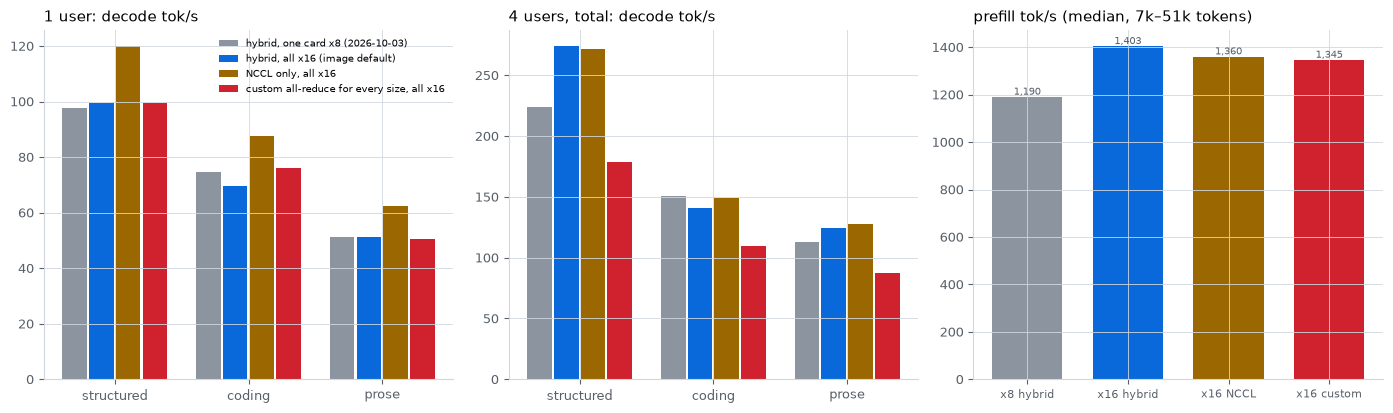

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
w = 0.2
for i, (d, lab) in enumerate(RUNS):
    for ax, c in ((axes[0], 1), (axes[1], 4)):
        ax.bar([j + (i - 1.5) * w for j in range(3)], [dec(d, p, c)[0] for p in PROMPTS], w * 0.92, color=S[i], label=lab)
    m = statistics.median(prefill(d))
    axes[2].bar(i, m, 0.7, color=S[i]); axes[2].text(i, m, f"{m:,.0f}", ha="center", va="bottom", fontsize=7, color=INK2)
for ax, c in ((axes[0], 1), (axes[1], 4)):
    ax.set_xticks(range(3), PROMPTS); ax.set_title(f"{'1 user' if c == 1 else '4 users, total'}: decode tok/s", loc="left")
axes[2].set_xticks(range(4), ["x8 hybrid", "x16 hybrid", "x16 NCCL", "x16 custom"], fontsize=8)
axes[2].set_title("prefill tok/s (median, 7k–51k tokens)", loc="left")
axes[0].legend(fontsize=7, frameon=False, loc="upper right")
fig.tight_layout()
for ext in ("png", "svg"):
    fig.savefig(f"../assets/charts/2026-10-04-deepseek-v4.1-flash-exl3-4card-tp4ep4-x16-allreduce-vllm.{ext}", dpi=150)
plt.show()

- **Measured:** the link change helps where the cards exchange the most data: four users (+22% on structured) and long prompts (prefill median +18%). One user sends about 61 KB per all-reduce, so one-user decode does not depend on the link width.
- **Measured:** the code result of the x16 hybrid run (69.7 tok/s) comes with fewer accepted tokens per step (3.30) than the other runs (3.50–3.71). Compare rows at the same `acc`.
- **Recommended:** `CUSTOM_AR=0 VLLM_FORCE_CUSTOM_AR_PCIE=0` (NCCL only) on hosts with all cards at x16. Keep the image default on hosts with a narrower link until it is measured there.

## 3. What this does not show (untested)

- Power above 140 W, and NCCL P2P levels: this engine does not set `NCCL_P2P_LEVEL`, so NCCL chooses its own path (the setting that helped GLM-5.3-Flash on this host).
- The fp8 Engram tier from disk at x16 (the int4 tier is served; its accuracy caveat from the 2026-10-03 notebook still applies).
- Run-to-run spread: one boot per configuration.

## 4. Reproduce

Unchanged from the [2026-10-03 notebook](2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm.ipynb), section 8 (weights, int4 tables, pack, serve command with `ghcr.io/pixelml/club-170hx@sha256:b8b7a1699bf272855a9b8c8b316f796b3ef917696302baf2a62c856707d69932`). For the other two arms add `-e CUSTOM_AR=0 -e VLLM_FORCE_CUSTOM_AR_PCIE=0` (NCCL only) or `-e VLLM_CUSTOM_AR_MAX_BYTES=0` (custom for every size) to `docker run`. The bench: `bench_long.py`, `bench_decode.py` and `correct.py` from `results/2026-10-03-deepseek-v4.1-flash-exl3-4card-tp4ep4-dspark-vllm/`; the loop that ran them is `results/2026-10-04-deepseek-v4.1-flash-exl3-4card-tp4ep4-x16-allreduce-vllm/chain.sh`.

## Try your own prompt

Edit `PROMPT`. With `LIVE = False`, the cell prints the recorded known-answer results of the served configuration.

In [6]:
PROMPT = "What is the capital of Australia? One word."
if LIVE:
    import urllib.request
    url = os.environ[ENDPOINT_ENV_VAR]
    body = {"model": "deepseek-v4.1-flash", "messages": [{"role": "user", "content": PROMPT}], "max_tokens": 200, "temperature": 0}
    req = urllib.request.Request(url + "/chat/completions", json.dumps(body).encode(), {"Content-Type": "application/json"})
    resp = json.load(urllib.request.urlopen(req, timeout=600))
    print(resp["choices"][0]["message"].get("content")); print(resp["usage"])
else:
    j = json.load(open(RECEIPTS + "/int4-hybrid-x16/correctness.json"))
    for c in j["cases"]:
        print({k: (str(v)[:80] if isinstance(v, str) else v) for k, v in c.items()})

{'prompt': 'What is 17 * 23? Answer with the number only.', 'expect': '391', 'content': '391', 'reasoning_chars': 55, 'completion_tokens': 20, 'pass': True}
{'prompt': 'What is the capital of Australia? One word.', 'expect': 'Canberra', 'content': 'Canberra', 'reasoning_chars': 73, 'completion_tokens': 20, 'pass': True}
{'prompt': 'A train leaves at 09:40 and arrives at 13:15. How many minutes is the trip? Answ', 'expect': '215', 'content': '215', 'reasoning_chars': 128, 'completion_tokens': 47, 'pass': True}
{'prompt': 'Write a Python function is_prime(n). Then state what is_prime(97) returns, as th', 'expect': 'RESULT=True', 'content': '```python\ndef is_prime(n):\n    if n < 2:\n        return False\n    for i in range', 'reasoning_chars': 383, 'completion_tokens': 160, 'pass': True}
{'prompt': 'Spell the word ELEPHANT backwards, uppercase, no spaces.', 'expect': 'TNAHPELE', 'content': 'TNAHPELE', 'reasoning_chars': 173, 'completion_tokens': 62, 'pass': True}
